### <a name="f2"></a>Function 2
- **Inputs**: 2d array (10, 2)
- **Ouput**: 1d array (10,)
- **Goal**: Maximise
- **Description**: Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import os
import sys
from IPython.display import display, Math, Latex

src = os.path.expanduser("~/repos/capstone_imperial_ml_ai/src")
if src not in sys.path:
    sys.path.append(src)

from ml.data import DataLoader, TransformUtils
from ml.plot import PlotUtils

import numpy as np

In [13]:
data = DataLoader.DATA['f2']
df = DataLoader.to_pandas(data=data)
X, y = df[['X_0', 'X_1']].values, df['y'].values

<Axes: xlabel='X_0', ylabel='X_1'>

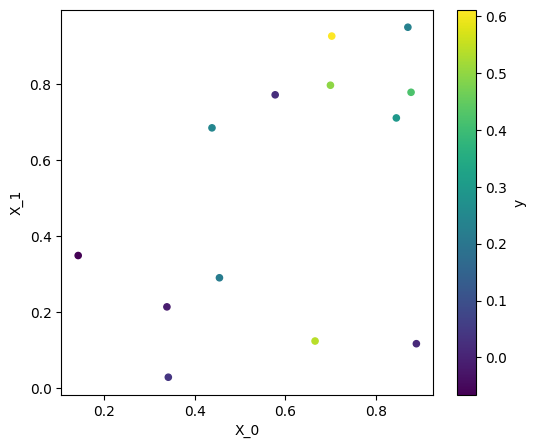

In [14]:
df.plot.scatter(x='X_0', y='X_1', c='y', colormap='viridis', figsize=(6,5))

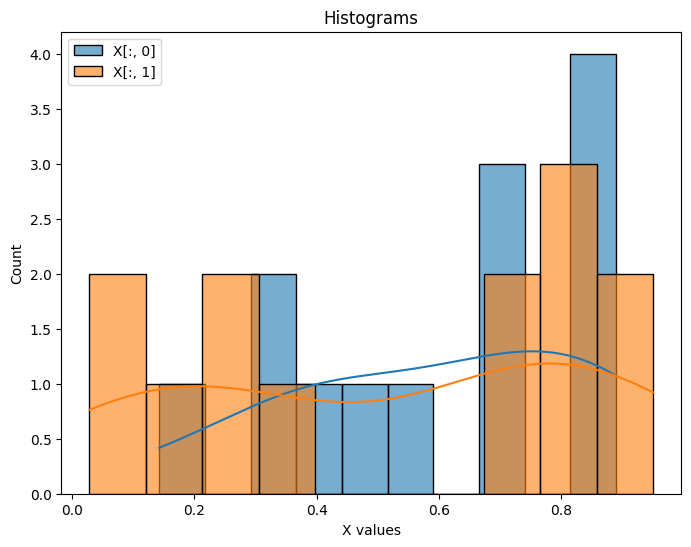

In [15]:
PlotUtils.histogram(X, bins=10)
# PlotUtils.scatter(X, y)

### Data
- Exploring the data we can see that there is a gap for values of the `X_1` features between `~0.3` and `~0.7`. As a result the function of the value is unknown for these range. 
- There are no outliers and no discernible pattern visually. Although higher values of `y` are generally found with higher values of `X_0` and `X_1`.

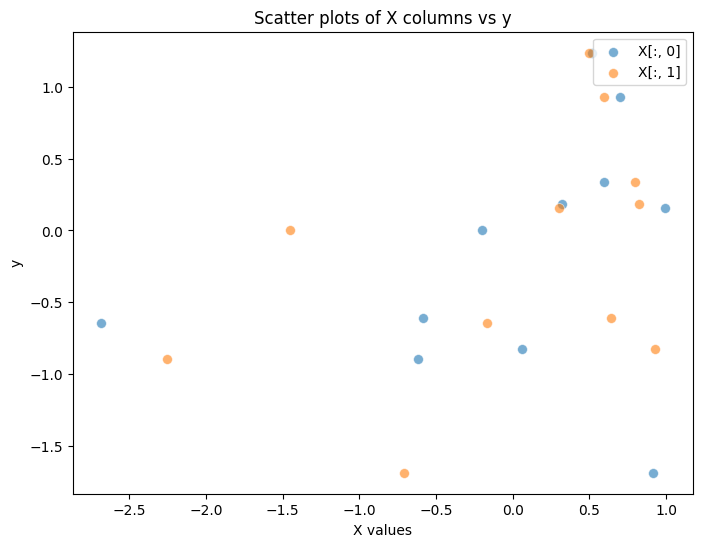

In [33]:
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import make_pipeline

x_scaler = StandardScaler(with_mean=True, with_std=True)
y_scaler = RobustScaler()

x_log = np.log(np.abs(X))
y_log = np.log(np.abs(y)).reshape(-1, 1)

X_transformed = x_scaler.fit_transform(x_log)
y_transformed = y_scaler.fit_transform(y_log).ravel()

PlotUtils.scatter(X_transformed, y_transformed)

In [36]:

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel

# 1. Matern(nu=2.5): The 5/2 kernel we discussed.
# 2. WhiteKernel: This handles "Noise". It tells the model 
#    "The data isn't perfect, allow for some wiggle room."
kernel = Matern(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 10.0), nu=2.5) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-5, 1e1))

model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=100, normalize_y=True)

model.fit(X_transformed, y_transformed)


print("Model Trained.")
print(f"Learned Kernel Parameters: {model.kernel_}")


/workspaces/capstone_imperial_ml_ai/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,kernel,Matern(length...e_level=1e-05)
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,100
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,"Matern(length...1, 1], nu=2.5)"
,kernel__k2,WhiteKernel(noise_level=1e-05)
,kernel__k1__length_scale,"[1.0, 1.0]"


Model Trained.
Learned Kernel Parameters: Matern(length_scale=[0.541, 0.348], nu=2.5) + WhiteKernel(noise_level=1e-05)


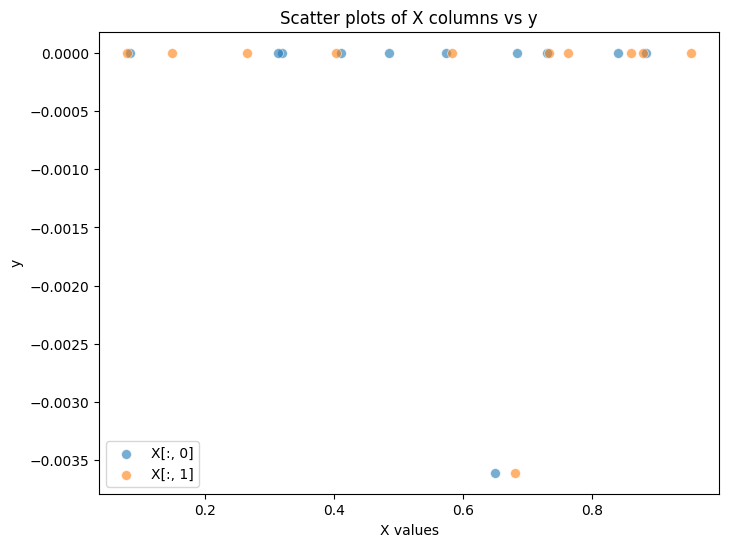

In [37]:
PlotUtils.scatter(X, y)

In [38]:
def predict(X_new):
    X_new_log = np.log(np.abs(X_new))
    X_new_transformed = x_scaler.transform(X_new_log)
    y_pred_transformed, y_std_transformed = model.predict(X_new_transformed, return_std=True)
    y_pred_log = y_scaler.inverse_transform(y_pred_transformed.reshape(-1, 1)).ravel()
    y_pred = -1 * np.exp(y_pred_log)
    return y_pred, y_std_transformed

x_space = np.linspace(0.6, 0.70, 10)
x_space = np.array([[x1, x1] for x1 in x_space])
y_pred, y_std = predict(x_space)
print("Predictions:")
for xi, yi, si in zip(x_space, y_pred, y_std):
    print(f"X: {xi}, Predicted y: {yi}, Std Dev: {si}")

Predictions:
X: [0.6 0.6], Predicted y: -3.664784535203939e-15, Std Dev: 0.3917233745049321
X: [0.61111111 0.61111111], Predicted y: -4.169900729852821e-12, Std Dev: 0.33132196432897026
X: [0.62222222 0.62222222], Predicted y: -1.9596185654646737e-09, Std Dev: 0.270046420254736
X: [0.63333333 0.63333333], Predicted y: -3.019347173077998e-07, Std Dev: 0.21038446376426714
X: [0.64444444 0.64444444], Predicted y: -1.2297589890789692e-05, Std Dev: 0.15590480011073474
X: [0.65555556 0.65555556], Predicted y: -0.00011052347989128152, Std Dev: 0.11187958714260506
X: [0.66666667 0.66666667], Predicted y: -0.00019409481248535264, Std Dev: 0.08506166798369336
X: [0.67777778 0.67777778], Predicted y: -6.428195930670953e-05, Std Dev: 0.0770199308332287
X: [0.68888889 0.68888889], Predicted y: -4.2843683074472846e-06, Std Dev: 0.07672131379393245
X: [0.7 0.7], Predicted y: -6.655986384208632e-08, Std Dev: 0.07182209041621763


In [ ]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize

def expected_improvement(x, model, y_best, xi=0.01):
    """
    Computes the EI at point x based on the GP model.
    """
    # FIX: Reshape to (1, n_features) so sklearn sees 1 sample with N features
    x_2d = x.reshape(1, -1)
    
    # 1. Ask the model for the mean and standard deviation
    mu, sigma = model.predict(x_2d, return_std=True)
    
    # 2. Calculate the improvement logic
    with np.errstate(divide='warn'):
        imp = mu - y_best - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        
        # Handle cases where sigma is 0 (we've already drilled here)
        ei[sigma == 0.0] = 0.0

    return ei

def propose_next_location(model, y_best, bounds, n_restarts=25):
    """
    Finds the x that maximizes Expected Improvement.
    """
    # Ensure bounds are in the right format for the optimizer
    dim = len(bounds)
    min_val = 1
    min_x = None
    
    # Randomly initialize the search N times to avoid local optima
    # We generate random starting points within the bounds for each dimension
    random_starts = np.random.uniform(
        low=[b[0] for b in bounds], 
        high=[b[1] for b in bounds], 
        size=(n_restarts, dim)
    )
    
    for x0 in random_starts:
        res = minimize(lambda x: -expected_improvement(x, model, y_best), 
                       x0=x0, 
                       bounds=bounds, 
                       method='L-BFGS-B')
        
        if res.fun < min_val:
            min_val = res.fun
            min_x = res.x
            
    return min_x.reshape(1, -1)

In [9]:
def get_bounds(X_final):
    """
    Calculate safe bounds for the optimization based on the empirical data.
    Adds a buffer to allow exploration outside the current sampled region.
    """
    # Assuming X_final is your scaled input array (N_samples, N_features)

    # 1. Calculate the empirical min and max for each feature (dimension)
    x_min = np.min(X_final, axis=0)
    x_max = np.max(X_final, axis=0)

    # 2. Add a small buffer (e.g., 25%) for exploration outside the current sampled region
    buffer = 0.25 # Adds 25% extra room on either side

    # 3. Create the final bounds list of tuples
    bounds_list = []
    for i in range(X_final.shape[1]): # Iterate through each feature
        # Calculate the range and buffer size
        feature_range = x_max[i] - x_min[i]
        buffer_size = feature_range * buffer
        
        # Define the new bounds (min - buffer, max + buffer)
        new_min = x_min[i] - buffer_size
        new_max = x_max[i] + buffer_size
        
        bounds_list.append((new_min, new_max))

    # bounds_list is now the correct variable to pass to propose_next_location
    print("Calculated Safe Bounds:", bounds_list)

    return bounds_list



In [41]:
# ... (Assume 'model' is your fitted Gaussian Process from the previous step)
# ... (Assume 'y_final' is your scaled, log-transformed target data)

# 1. Identify the current record holder (in Log Space)
current_best_y = np.max(y)

# 2. Define the bounds of your input space (e.g., 0 to 1)
bounds = [
    (-2., 1.5), # Bounds for Feature 1
    (-2, 1.5)  # Bounds for Feature 2
]
bounds = get_bounds(X_transformed)

# 3. Ask the Acquisition Function where to drill next
next_x_scaled_log = propose_next_location(model, current_best_y, bounds)

print(f"The Mathematical Compass says drill at X (scaled/log): {next_x_scaled_log}")

# 4. UN-TRANSFORM X to get the real coordinates for the competition
# (Assuming you log-scaled X as discussed earlier)
real_next_x = np.exp(x_scaler.inverse_transform(next_x_scaled_log))

print(f"Drill coordinate for submission: {real_next_x.tolist()}")

predicted_y, predicted_std = predict(real_next_x)
print(f"Predicted y at this location: {predicted_y}, with std dev: {predicted_std}")

Calculated Safe Bounds: [(np.float64(-3.603809637456644), np.float64(1.9099951505119503)), (np.float64(-3.0496340166242915), np.float64(1.7239040308595999))]
The Mathematical Compass says drill at X (scaled/log): [[0.48662214 0.49861033]]
Drill coordinate for submission: [[0.638371782454783, 0.6812481476782466]]
Predicted y at this location: [-0.0054263], with std dev: [0.03594]


In [ ]:

test_1, test_std = predict(np.array([[0.484425, 0.954131]]))
print(f"Test Prediction at [0.484425, 0.954131]: {test_1}, Std Dev: {test_std}")

Test Prediction at [0.484425, 0.954131]: [-1.25560587e-88], Std Dev: [0.00366699]


/workspaces/capstone_imperial_ml_ai/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,kernel,Matern(length...e_level=1e-05)
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,50
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,"Matern(length_scale=1, nu=2.5)"
,kernel__k2,WhiteKernel(noise_level=1e-05)
,kernel__k1__length_scale,1.0


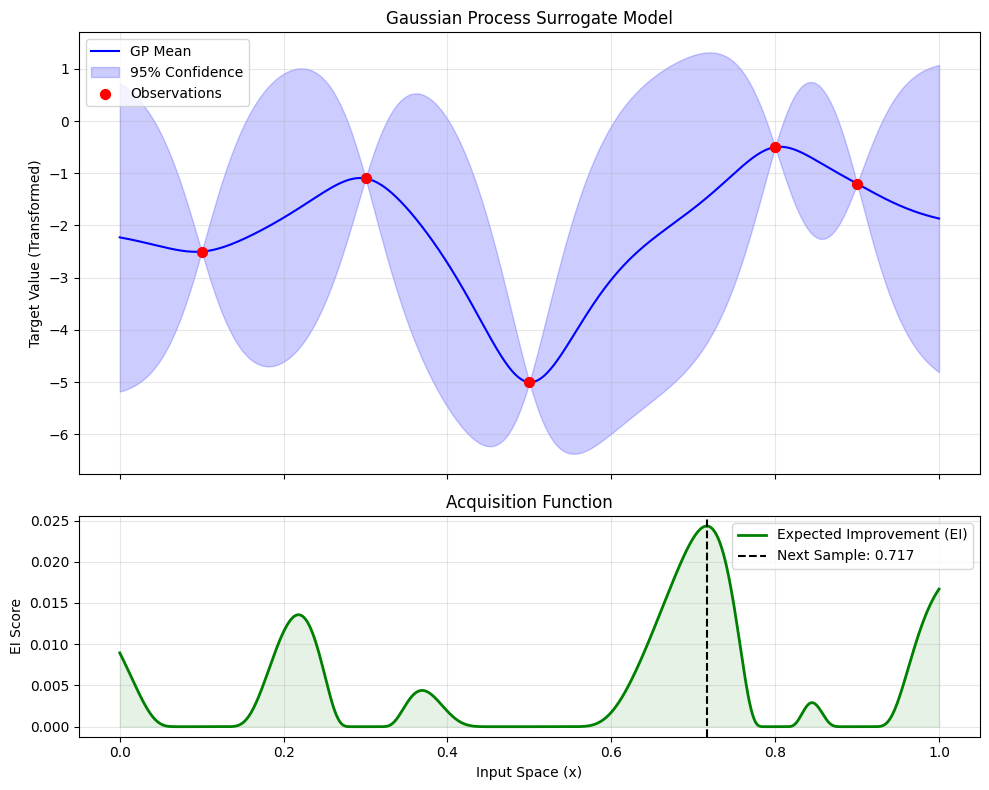

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.preprocessing import RobustScaler
from scipy.stats import norm

# --- 1. Helper Function: The Acquisition Function (Expected Improvement) ---
def expected_improvement(X, model, y_best, xi=0.01):
    """Calculates EI for a set of points X"""
    mu, sigma = model.predict(X, return_std=True)
    with np.errstate(divide='warn'):
        imp = mu - y_best - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# --- 2. The Plotting Function ---
def plot_bayesian_optimization(model, X_train, y_train, bounds, scaler_y=None):
    """
    Plots the GP model (Top) and Acquisition Function (Bottom).
    
    Args:
        model: The trained GaussianProcessRegressor
        X_train: The raw input data (scaled internally for prediction if needed)
        y_train: The raw output data (log-transformed internally)
        bounds: The limits of the search space [(min, max), ...]
        scaler_y: The scaler used on y (optional, for un-scaling plots)
    """
    
    # A. Create a grid of points to plot the smooth lines
    x_grid = np.linspace(bounds[0][0], bounds[0][1], 1000).reshape(-1, 1)
    # B. Get Model Predictions (Mean & Uncertainty) on the grid
    # Note: These predictions are in "Transformed Space" (Log-Scaled)
    mu, sigma = model.predict(x_grid, return_std=True)
    
    # C. Calculate Acquisition Function (EI) on the grid
    # We look for improvement over the best CURRENT observed value
    y_best_current = np.max(model.y_train_) 
    ei = expected_improvement(x_grid, model, y_best_current)
    
    # --- D. PLOTTING ---
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    
    # Top Plot: The Surrogate Model
    ax1 = axes[0]
    ax1.plot(x_grid, mu, 'b-', label='GP Mean')
    ax1.fill_between(x_grid.ravel(), 
                     mu - 1.96 * sigma, 
                     mu + 1.96 * sigma, 
                     alpha=0.2, 
                     color='blue', 
                     label='95% Confidence')
    
    # Plot the actual data points (training data)
    ax1.scatter(X_train, y_train, c='red', s=50, zorder=10, label='Observations')
    
    ax1.set_title("Gaussian Process Surrogate Model")
    ax1.set_ylabel("Target Value (Transformed)")
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # Bottom Plot: The Acquisition Function
    ax2 = axes[1]
    ax2.plot(x_grid, ei, 'g-', linewidth=2, label='Expected Improvement (EI)')
    ax2.fill_between(x_grid.ravel(), ei, 0, color='green', alpha=0.1)
    
    # Highlight the next best point
    next_x_idx = np.argmax(ei)
    next_x = x_grid[next_x_idx]
    ax2.axvline(next_x, color='k', linestyle='--', label=f'Next Sample: {next_x[0]:.3f}')
    
    ax2.set_title("Acquisition Function")
    ax2.set_xlabel("Input Space (x)")
    ax2.set_ylabel("EI Score")
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- 3. Example Usage with your settings ---

# Mock Data (already scaled X, log-transformed y)
X_train_example = np.array([0.1, 0.3, 0.5, 0.8, 0.9]).reshape(-1, 1)
y_train_example = np.array([-2.5, -1.1, -5.0, -0.5, -1.2]) # Log-transformed values

# Define and Train Model
kernel = Matern(length_scale=1.0, nu=2.5) + WhiteKernel(noise_level=1e-5)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=50)
gp.fit(X_train_example, y_train_example)

# VISUALIZE
# Bounds should match your X scaling (0 to 1 if using MinMax/Robust properly)
plot_bayesian_optimization(gp, X_train_example, y_train_example, bounds=[(0, 1)])

,kernel,RBF(length_scale=0.1)
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,False
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__length_scale,0.1
,kernel__length_scale_bounds,'fixed'


Text(0, 0.5, 'f(x)')

Text(0.5, 0, 'x')

(0.0, 1.0)

(0.0, 1.9896017356559526)

Text(0.5, 1.0, 'Real function and all queries')

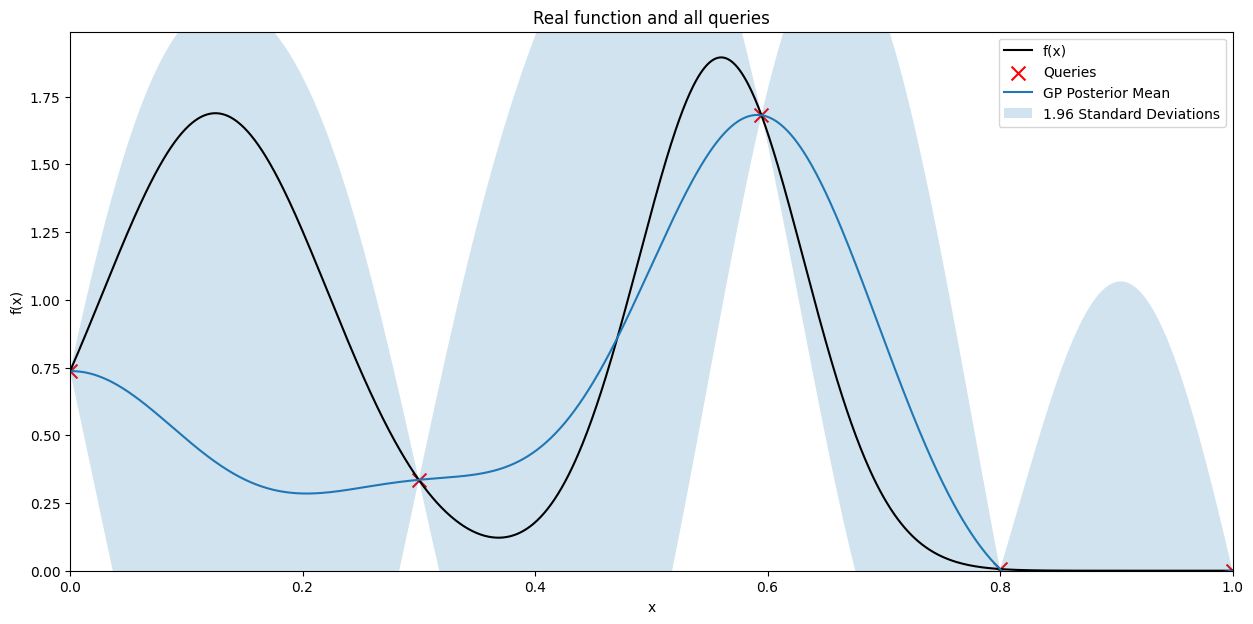

Maximum (by Grid-Search):
1.8948587962503307
UCB (Acquisition Function by Grid-Search):
1.6811975942925428


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm

#Parameters of the problem. Feel free to change them and play around with them.
real_noise_std = 1e-10  #Needs to be positive for code to work, instead of zero set 1e-10
noise_assumption = 1e-10

rbf_lengthscale = 0.1

#Acquisition function parameter (not used for variance-based acquisition)
beta = 1.96

#Draw random function parameters
modes = np.random.randint(1, 5)
std = np.random.uniform(low=0.005, high=0.05, size=modes)
means = np.random.uniform(size=modes)
amps = np.random.uniform(size=modes) * (2 - 1) + 1

#Define function
def calc_function(x):
    exp = -(x - means) ** 2 / std
    y = amps * np.exp(exp)
    return np.sum(y)

#Define the kernel of the GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)

#Initialise query lists and maximum observations
X, Y = [], []
max_obs = 0
#Initialise grid for plots
x_grid = np.linspace(0, 1, 101).reshape(-1, 1)

#Number of queries in the optimisation loop
num_queries = 5

for i in range(0, num_queries):
    #Clear the outputs to keep the interface clean
    clear_output(wait=True)
    model = GaussianProcessRegressor(kernel=kernel)
    #Fit the model
    if i != 0:
        model.fit(np.array(X).reshape(-1, 1), np.array(Y).reshape(-1, 1))
    #Calculate the mean and standard deviation and make them one-dimensional for plotting
    post_mean, post_std = model.predict(x_grid, return_std=True)
    post_mean, post_std = post_mean.squeeze(), post_std.squeeze()

    #Initialise plots
    fig, ax = plt.subplots(figsize=(15, 7))
    #Set the x and y limits, labels and dynamic title
    ax.set_xlim(0, 1)
    ax.set_ylim(0, max(max_obs + 1, 3))
    ax.set_ylabel('f(x)')
    ax.set_xlabel('x')
    ax.set_title('So far you have selected ' + str(i) + ' queries, you have ' + str(10 - i) + ' left.')
    #Plot queries
    ax.scatter(X, Y, c='r', marker='x', s=100)
    #Plot the mean and standard deviation
    ax.plot(x_grid.squeeze(), post_mean, label='GP Posterior Mean')
    ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha=0.2, label=str(beta) + ' Standard Deviations')
    ax.legend()
    plt.show()
    #Initialise x
    x = -1
    #Select a display format for X and Y
    X_format = ['%.2f' % query for query in X]  #Two sig figs
    Y_format = ['%.4f' % obs for obs in Y]      #Four sig figs

    data = [(query, obs) for query, obs in zip(X_format, Y_format)]
    print('Data so far (sorted by descending observations): ')
    print('\n'.join('{}: (x, f(x)) = {}'.format(*k) for k in enumerate(data, start=1)))  #Display data
    _ = input('Input anything to see the next chosen point')  #You are using this to allow the user to change plots


    acquisition_function = post_std ** 2  #Variance-based acquisition

   
    if i == 0:
        x = np.random.uniform(0, 1)  #The first observation is chosen randomly
    else:
        grid = x_grid.squeeze()
        x = grid[np.argmax(acquisition_function)]  #Else use the acquisition function

    #Append data, calculate function and sort lists according to observation values
    X.append(x)
    y = calc_function(x) + np.random.normal(scale=real_noise_std)
    Y.append(y)
    X = [x for _, x in sorted(zip(Y, X), reverse=True)]
    Y.sort(reverse=True)
    max_obs = max(max_obs, y)

clear_output()

#Calculate function in the grid [0, 0.01, 0.02, ..., 0.98, 0.99, 1]
x_grid = np.linspace(0, 1, 1001)
y_real = []
best_obs_grid = 0
for x in x_grid:
    y = calc_function(x)
    y_real.append(y)
    best_obs_grid = max(best_obs_grid, y)  #Keep track of the best observation

#Final GP posterior
model.fit(np.array(X).reshape(-1, 1), np.array(Y).reshape(-1, 1))
post_mean, post_std = model.predict(x_grid.reshape(-1, 1), return_std=True)
post_mean, post_std = post_mean.squeeze(), post_std.squeeze()

#Final plot and display
fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(x_grid, y_real, 'k', label='f(x)')
ax.scatter(X, Y, c='r', marker='x', label='Queries', s=100)
ax.set_ylabel('f(x)')
ax.set_xlabel('x')
ax.set_xlim(0, 1)
ax.set_ylim(bottom=0)
ax.set_title('Real function and all queries')
ax.plot(x_grid.squeeze(), post_mean, label='GP Posterior Mean')
ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha=0.2, label=str(beta) + ' Standard Deviations')
ax.legend()
plt.show()
print('Maximum (by Grid-Search):')
print(best_obs_grid)
print('UCB (Acquisition Function by Grid-Search):')
print(max_obs)